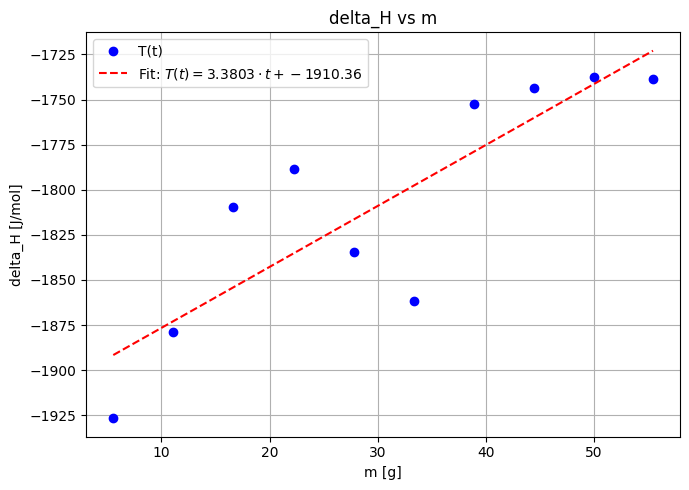

0     5.5526
1    11.0889
2    16.6640
3    22.2195
4    27.7644
5    33.3133
6    38.8708
7    44.4215
8    49.9531
9    55.4397
Name: m, dtype: float64
0   -1926.662789
1   -1878.712604
2   -1809.565784
3   -1788.439962
4   -1834.708144
5   -1861.453686
6   -1752.379533
7   -1743.886048
8   -1737.315582
9   -1738.484794
Name: delta_H, dtype: float64


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei einlesen
# ===============================
df = pd.read_excel("Exp6_Kalorimetrie_Template_2025.xlsx", engine="openpyxl",
                   sheet_name="Kalorimetrie Template",
                   usecols="K,J",
                   skiprows=8,
                   nrows=10)

# ===============================
# Spaltennamen setzen und bereinigen
# ===============================
df.columns = ["delta_H", "m"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# ===============================
# Lineare Regression
# ===============================
x = df["m"].values                  # Zeit auf x-Achse
y = df["delta_H"].values           # Temperatur auf y-Achse

coeffs = np.polyfit(x, y, deg=1)
fit_line = np.poly1d(coeffs)

x_fit = np.linspace(min(x), max(x), 200)
y_fit = fit_line(x_fit)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', color='blue', label="T(t)")
plt.plot(x_fit, y_fit, 'r--', label=fr'Fit: $T(t) = {coeffs[0]:.4f} \cdot t + {coeffs[1]:.2f}$')

plt.xlabel("m [g]")
plt.ylabel("delta_H [J/mol]")
plt.title("delta_H vs m")

plt.ticklabel_format(axis='y', style='plain')  # Kein wissenschaftliches Format für y
plt.ticklabel_format(axis='x', style='plain')  # NEU: auch x-Achse normal formatieren
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
print(df["m"])
print(df["delta_H"])

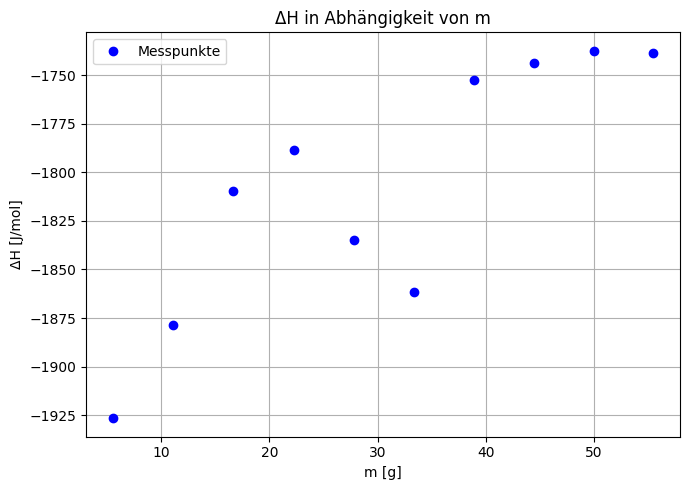

0     5.5526
1    11.0889
2    16.6640
3    22.2195
4    27.7644
5    33.3133
6    38.8708
7    44.4215
8    49.9531
9    55.4397
Name: m, dtype: float64
0   -1926.662789
1   -1878.712604
2   -1809.565784
3   -1788.439962
4   -1834.708144
5   -1861.453686
6   -1752.379533
7   -1743.886048
8   -1737.315582
9   -1738.484794
Name: delta_H, dtype: float64


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei einlesen
# ===============================
df = pd.read_excel("Exp6_Kalorimetrie_Template_2025.xlsx", engine="openpyxl",
                   sheet_name="Kalorimetrie Template",
                   usecols="K,J",
                   skiprows=8,
                   nrows=10)

# ===============================
# Spaltennamen setzen und bereinigen
# ===============================
df.columns = ["delta_H", "m"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# ===============================
# Daten extrahieren
# ===============================
x = df["m"].values
y = df["delta_H"].values

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', color='blue', label="Messpunkte")

plt.xlabel("m [g]")
plt.ylabel("ΔH [J/mol]")
plt.title("ΔH in Abhängigkeit von m")

plt.ticklabel_format(axis='y', style='plain')
plt.ticklabel_format(axis='x', style='plain')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Kontrolle
# ===============================
print(df["m"])
print(df["delta_H"])

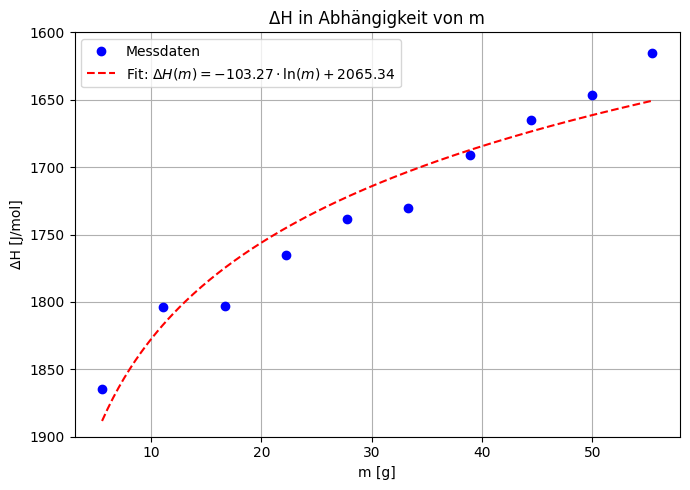

       delta_H        m
0  1864.675509   5.5526
1  1803.670542  11.0889
2  1803.019365  16.6640
3  1765.519847  22.2195
4  1738.479595  27.7644
5  1730.599176  33.3133
6  1691.190475  38.8708
7  1665.342406  44.4215
8  1646.130455  49.9531
9  1615.073363  55.4397


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei einlesen
# ===============================
df = pd.read_excel("Exp6_Kalorimetrie_Template_2025.xlsx", engine="openpyxl",
                   sheet_name="Kalorimetrie Template",
                   usecols="K,J",
                   skiprows=8,
                   nrows=10)

# ===============================
# Spaltennamen setzen und bereinigen
# ===============================
df.columns = ["delta_H", "m"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# ===============================
# Werte extrahieren
# ===============================
x = df["m"].values
y = df["delta_H"].values

# ===============================
# Log-Funktion definieren
# ===============================
def log_func(x, a, b):
    return a * np.log(x) + b

# Fit durchführen (nur positive x-Werte erlaubt!)
x_pos = x[x > 0]
y_pos = y[x > 0]
popt, _ = curve_fit(log_func, x_pos, y_pos)
a_fit, b_fit = popt

# Fit-Kurve erzeugen
x_fit = np.linspace(min(x_pos), max(x_pos), 200)
y_fit = log_func(x_fit, a_fit, b_fit)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', color='blue', label="Messdaten")
plt.plot(x_fit, y_fit, '--', color='red',
         label=fr'Fit: $\Delta H(m) = {a_fit:.2f} \cdot \ln(m) + {b_fit:.2f}$')

plt.xlabel("m [g]")
plt.ylabel("ΔH [J/mol]")
plt.title("ΔH in Abhängigkeit von m")

plt.ticklabel_format(axis='y', style='plain')
plt.ylim(1900, 1600)  # ⬅️ Y-Achse hier anpassen
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Kontrolle
# ===============================
print(df)

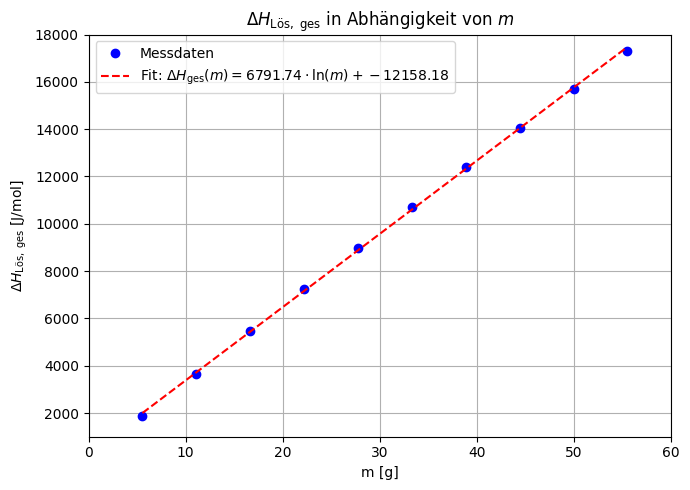

         m         H_ges
0   5.5526   1864.675509
1  11.0889   3668.346051
2  16.6640   5471.365415
3  22.2195   7236.885262
4  27.7644   8975.364857
5  33.3133  10705.964034
6  38.8708  12397.154509
7  44.4215  14062.496914
8  49.9531  15708.627369
9  55.4397  17323.700732


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei einlesen
# ===============================
df = pd.read_excel("Exp6_Kalorimetrie_Template_2025.xlsx", engine="openpyxl",
                   sheet_name="Kalorimetrie Template",
                   usecols="K,M",
                   skiprows=8,
                   nrows=10)

# ===============================
# Spaltennamen setzen und bereinigen
# ===============================
df.columns = ["m", "H_ges"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# ===============================
# Werte extrahieren
# ===============================
x = df["m"].values
y = df["H_ges"].values

# ===============================
# Lineare Regression
# ===============================
x = df["m"].values                  # Zeit auf x-Achse
y = df["H_ges"].values           # Temperatur auf y-Achse

coeffs = np.polyfit(x, y, deg=1)
fit_line = np.poly1d(coeffs)

x_fit = np.linspace(min(x), max(x), 200)
y_fit = fit_line(x_fit)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', color='blue', label="Messdaten")
plt.plot(x_fit, y_fit, '--', color='red',
         label=fr'Fit: $ΔH_{{\mathrm{{ges}}}}(m) = {a_fit:.2f} \cdot \ln(m) + {b_fit:.2f}$')

plt.xlabel("m [g]")
plt.ylabel(r"$\Delta H_{\mathrm{Lös,\ ges}}$ [J/mol]")
plt.title(r"$\Delta H_{\mathrm{Lös,\ ges}}$ in Abhängigkeit von $m$")

plt.ticklabel_format(axis='y', style='plain')
plt.xlim(0,60)  # ⬅️ Y-Achse hier anpassen
plt.ylim(1000, 18000)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Kontrolle
# ===============================
print(df)

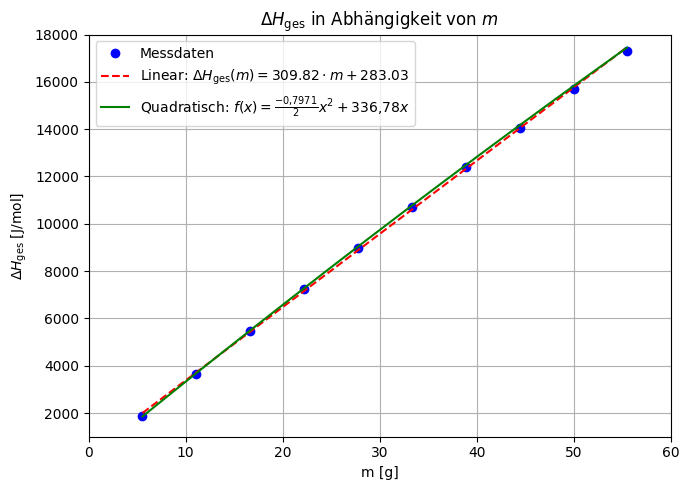

         m         H_ges
0   5.5526   1864.675509
1  11.0889   3668.346051
2  16.6640   5471.365415
3  22.2195   7236.885262
4  27.7644   8975.364857
5  33.3133  10705.964034
6  38.8708  12397.154509
7  44.4215  14062.496914
8  49.9531  15708.627369
9  55.4397  17323.700732


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei einlesen
# ===============================
df = pd.read_excel("Exp6_Kalorimetrie_Template_2025.xlsx", engine="openpyxl",
                   sheet_name="Kalorimetrie Template",
                   usecols="K,M",
                   skiprows=8,
                   nrows=10)

# ===============================
# Spaltennamen setzen und bereinigen
# ===============================
df.columns = ["m", "H_ges"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# ===============================
# Werte extrahieren
# ===============================
x = df["m"].values
y = df["H_ges"].values

# ===============================
# 1. Fit: Linear
# ===============================
coeffs_linear = np.polyfit(x, y, deg=1)
a_lin, b_lin = coeffs_linear
fit_linear = np.poly1d(coeffs_linear)

# ===============================
# 2. Fit: Deine quadratische Funktion
# ===============================
def custom_quad_func(x):
    return (-0.7971 / 2) * x**2 + 336.78 * x

# ===============================
# Fit-Kurven berechnen
# ===============================
x_fit = np.linspace(min(x), max(x), 200)
y_fit_lin = fit_linear(x_fit)
y_fit_quad = custom_quad_func(x_fit)

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', color='blue', label="Messdaten")
plt.plot(x_fit, y_fit_lin, '--', color='red',
         label=fr'Linear: $\Delta H_{{\mathrm{{ges}}}}(m) = {a_lin:.2f} \cdot m + {b_lin:.2f}$')
plt.plot(x_fit, y_fit_quad, '-', color='green',
         label=r'Quadratisch: $f(x) = \frac{-0{,}7971}{2}x^2 + 336{,}78x$')

plt.xlabel("m [g]")
plt.ylabel(r"$\Delta H_{\mathrm{ges}}$ [J/mol]")
plt.title(r"$\Delta H_{\mathrm{ges}}$ in Abhängigkeit von $m$")

plt.xlim(0, 60)
plt.ylim(1000, 18000)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Kontrolle
# ===============================
print(df)

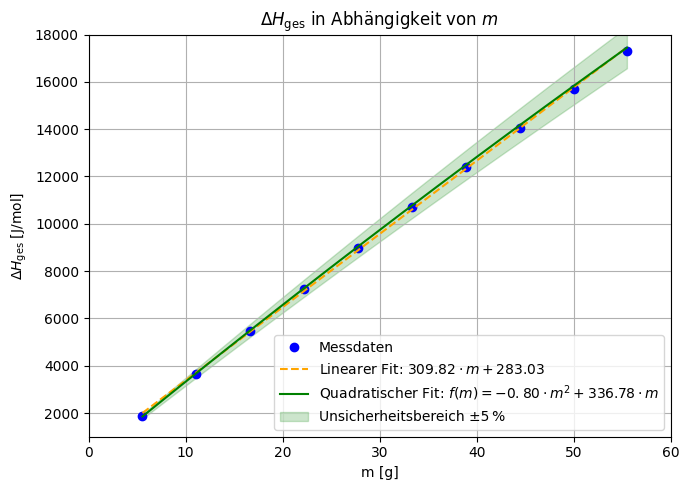

         m         H_ges
0   5.5526   1864.675509
1  11.0889   3668.346051
2  16.6640   5471.365415
3  22.2195   7236.885262
4  27.7644   8975.364857
5  33.3133  10705.964034
6  38.8708  12397.154509
7  44.4215  14062.496914
8  49.9531  15708.627369
9  55.4397  17323.700732


In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei einlesen
# ===============================
df = pd.read_excel("Exp6_Kalorimetrie_Template_2025.xlsx", engine="openpyxl",
                   sheet_name="Kalorimetrie Template",
                   usecols="K,M",
                   skiprows=8,
                   nrows=10)

# ===============================
# Spaltennamen setzen und bereinigen
# ===============================
df.columns = ["m", "H_ges"]
df = df.apply(pd.to_numeric, errors='coerce').dropna()

# ===============================
# Werte extrahieren
# ===============================
x = df["m"].values
y = df["H_ges"].values

# ===============================
# Linearer Fit
# ===============================
coeffs = np.polyfit(x, y, deg=1)
fit_line = np.poly1d(coeffs)

x_fit = np.linspace(min(x), max(x), 200)
y_fit_linear = fit_line(x_fit)

# ===============================
# Quadratischer Fit (manuell gegeben)
# f(x) = (-0.7971/2)·x² + 336.78·x
a = -0.7971 / 2
b = 336.78
y_fit_quad = a * x_fit**2 + b * x_fit

# Unsicherheitsbereich ±5 % um den quadratischen Fit
y_upper = y_fit_quad * 1.05
y_lower = y_fit_quad * 0.95

# ===============================
# Plot
# ===============================
plt.figure(figsize=(7, 5))
plt.plot(x, y, 'o', color='blue', label="Messdaten")
plt.plot(x_fit, y_fit_linear, '--', color='orange',
         label=fr'Linearer Fit: ${coeffs[0]:.2f} \cdot m + {coeffs[1]:.2f}$')
plt.plot(x_fit, y_fit_quad, '-', color='green',
         label=r'Quadratischer Fit: $f(m) = -0{.80} \cdot m^2 + 336.78 \cdot m$')

# Schattierter Unsicherheitsbereich
plt.fill_between(x_fit, y_lower, y_upper, color='green', alpha=0.2,
                 label="Unsicherheitsbereich ±5 %")

plt.xlabel("m [g]")
plt.ylabel(r"$\Delta H_{\mathrm{ges}}$ [J/mol]")
plt.title(r"$\Delta H_{\mathrm{ges}}$ in Abhängigkeit von $m$")
plt.ticklabel_format(axis='y', style='plain')
plt.grid(True)
plt.xlim(0, 60)
plt.ylim(1000, 18000)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Kontrolle
# ===============================
print(df)